In [117]:
import matplotlib.pyplot as plt
from os import walk
import json
import numpy as np 

In [122]:
log_origin  = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/origin-results/output-resnet18-O01/output-resnet_18-O1-1500.out'
log_new     = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/myversion-results/output-resnet18-M01/output-resnet18-O1-128.out'
log_new_all = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm//myversion-results/output-resnet18-M01-1500/output-resnet18-M1-1500.out'
hashs_log = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/myversion-results/output-resnet18-M02/output-resnet18.out'

In [123]:
h_file  = open(hashs_log, "r")
hashs_cached = []
for line in h_file:
    if('myhash' in line):
        h = line.split(' ')[1].replace('\n', '')
    if('cache size' in line):
        if(len(line.split(' ')) < 4):
            size = int(line.split(' ')[2].replace('\n', ''))
            if(size > 0):
                hashs_cached.append(h)


In [124]:
for h in hashs_cached:
    print(h)

d37380659057397544e056461ea3bad3
cb5e1bf27549411a1320749a1d8e07ca
d37380659057397544e056461ea3bad3
08f7449d79e570b7274174709e5e5e01
07f9fcad27bdd3233f86fe35a5185d33
cb5e1bf27549411a1320749a1d8e07ca
07f9fcad27bdd3233f86fe35a5185d33
07f9fcad27bdd3233f86fe35a5185d33
8c53ca2904398da2889aa7508082d7bb
cb5e1bf27549411a1320749a1d8e07ca
07f9fcad27bdd3233f86fe35a5185d33
c219de5fa5fe694343f2826ebe8e47ce
cfd09cf1ca9e943f0ee12a18813a5c75


In [125]:
f_origin  = open(log_origin, "r")
f_new     = open(log_new, "r")
f_new_all = open(log_new_all, "r")
result_origin_dic = {}
result_new_dic = {}
result_new_all_dic = {}
for line in f_new:
    if("task tune" in line):
        result = line.split("task tune:  ")[1].replace("\n", "")
        last = result.split(" ")
        last = last[len(last)-1]
        key = result.replace(" "+last, "")
        result_new_dic[key] = float(last)
for line in f_origin:
    if("task tune" in line):
        result = line.split("task tune:  ")[1].replace("\n", "")
        last = result.split(" ")
        last = last[len(last)-1]
        key = result.replace(" "+last, "")
        result_origin_dic[key] = float(last)
for line in f_new_all:
    if("task tune" in line):
        result = line.split("task tune:  ")[1].replace("\n", "")
        last = result.split(" ")
        last = last[len(last)-1]
        key = result.replace(" "+last, "")
        result_new_all_dic[key] = float(last)

In [126]:
speedup = []
speedup_all = []
for key in result_new_dic:
    if(key[2:34] in hashs_cached):
        speedup.append(result_origin_dic[key]/result_new_dic[key])
        speedup_all.append(result_origin_dic[key]/result_new_all_dic[key])

<BarContainer object of 11 artists>

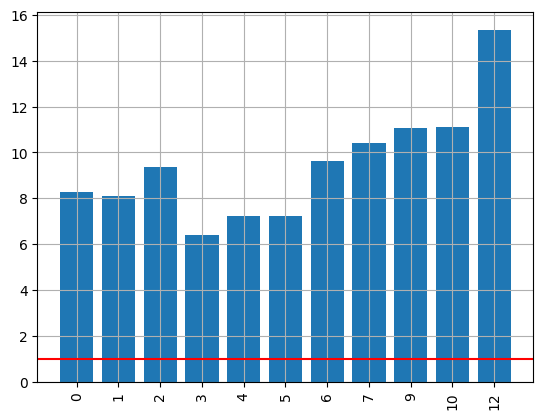

In [127]:
x = []
y = []
idx = 0
for v in np.arange(len(speedup)):
    if(v != 8 and v != 11):
        x.append(str(v))
        y.append(speedup[idx])
    idx += 1
plt.xticks(rotation=90)
plt.axhline(y=1, color='r', linestyle='-')
plt.grid()
plt.bar(x, y)


<BarContainer object of 13 artists>

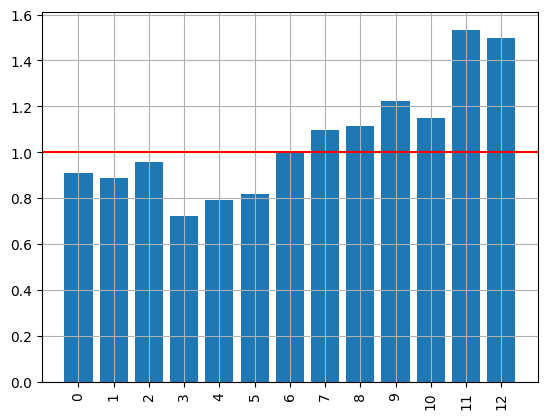

In [128]:
x = []
y = []
idx = 0
for v in np.arange(len(speedup_all)):
    if(v != 18 and v != 23):
        x.append(str(v))
        y.append(speedup_all[idx])
    idx += 1
plt.xticks(rotation=90)
plt.axhline(y=1, color='r', linestyle='-')
plt.grid()
plt.bar(x, y)

In [153]:
mypath_new = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/myversion-results/output-resnet18-M01/'
mypath_origin = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/origin-results/output-resnet18-O01/'
mypath_new_all = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/myversion-results/output-resnet18-M01-1500/'
mypath_sort = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/myversion-results/output-resnet18-M01-1000-sort/'

filenames_origin  = next(walk(mypath_origin), (None, None, []))[2]  # [] if no file
filenames_new     = next(walk(mypath_new), (None, None, []))[2]  # [] if no file
filenames_new_all = next(walk(mypath_new_all), (None, None, []))[2]  # [] if no file
filenames_sort = next(walk(mypath_sort), (None, None, []))[2]  # [] if no file

values_origin = {}
comp_origin = {}
for name in filenames_origin:
    if(".json" in name):
        f = open(mypath_origin + name, "r")
        best = 100000
        s = 0
        for line in f:
            result = json.loads(line)
            task = result['i'][0][0]
            r = sum(result['r'][0])/len(result['r'][0])
            if(task not in values_origin):
                values_origin[task] = []
                comp_origin[task] = []
            if(r < best):
                best = r
            if(r < 1000):
                s += r
                values_origin[task].append(best)
                comp_origin[task].append(s)

values_new = {}
for name in filenames_new:
    if(".json" in name):
        f = open(mypath_new + name, "r")
        best = 100000
        for line in f:
            result = json.loads(line)
            task = result['i'][0][0]
            r = sum(result['r'][0])/len(result['r'][0])
            if(task not in values_new):
                values_new[task] = []
            if(r < best):
                best = r
            if(r < 1000):
                values_new[task].append(r)

values_new_all = {}
for name in filenames_new_all:
    if(".json" in name):
        f = open(mypath_new_all + name, "r")
        best = 100000
        for line in f:
            result = json.loads(line)
            task = result['i'][0][0]
            r = sum(result['r'][0])/len(result['r'][0])
            if(task not in values_new_all):
                values_new_all[task] = []
            if(r < best):
                best = r
            if(r < 1000):
                values_new_all[task].append(best)

values_sort = {}
comp_sort = {}
for name in filenames_sort:
    if(".json" in name):
        f = open(mypath_sort + name, "r")
        best = 100000
        s = 0
        for line in f:
            result = json.loads(line)
            task = result['i'][0][0]
            r = sum(result['r'][0])/len(result['r'][0])
            if(task not in values_sort):
                values_sort[task] = []
                comp_sort[task] = []
            if(r < best):
                best = r
            if(r < 1000):
                s += r
                values_sort[task].append(best)
                comp_sort[task].append(s)

In [131]:
speedup = []
speedup_all = []
speedup_sum = []
speedup_real = []
speedup_sum_real = []
for idx, key in enumerate(values_new):
    if(len(values_new[key])):
        if(key[2:34] in hashs_cached):
            speedup.append(min(values_origin[key])/min(values_new_all[key][:128]))
            speedup_real.append(min(values_origin[key][0:64])/min(values_new_all[key][:64]))
            speedup_all.append(min(values_origin[key])/min(values_new_all[key]))
            #speedup_sum.append(sum(values_origin[key])/sum(values_new_all[key]))
            #speedup_sum_real.append(sum(values_origin[key][0:64])/sum(values_new[key][0:64]))

<BarContainer object of 12 artists>

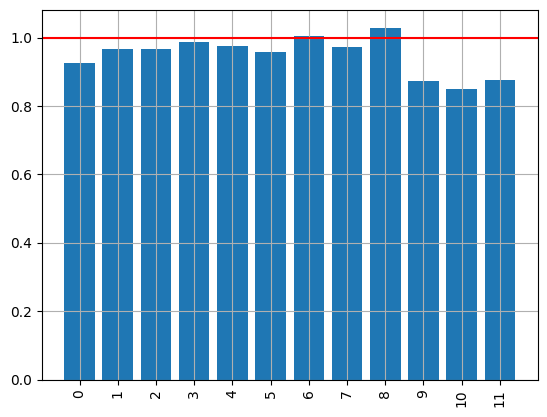

In [132]:
x = []
for v in np.arange(len(speedup)):
    x.append(str(v))
plt.axhline(y=1, color='r', linestyle='-')
plt.xticks(rotation=90)
plt.grid()
plt.bar(x, speedup)

<BarContainer object of 12 artists>

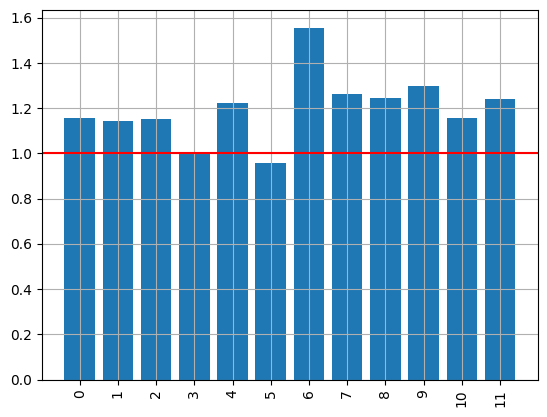

In [133]:
x = []
for v in np.arange(len(speedup_real)):
    x.append(str(v))
plt.axhline(y=1, color='r', linestyle='-')
plt.xticks(rotation=90)
plt.grid()
plt.bar(x, speedup_real)

<BarContainer object of 12 artists>

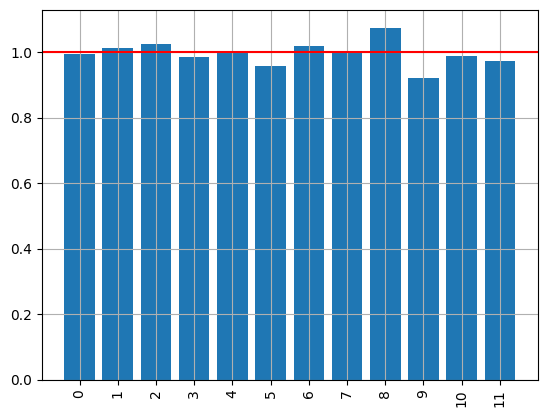

In [134]:
x = []
for v in np.arange(len(speedup_all)):
    x.append(str(v))
plt.axhline(y=1, color='r', linestyle='-')
plt.xticks(rotation=90)
plt.grid()
plt.bar(x, speedup_all)

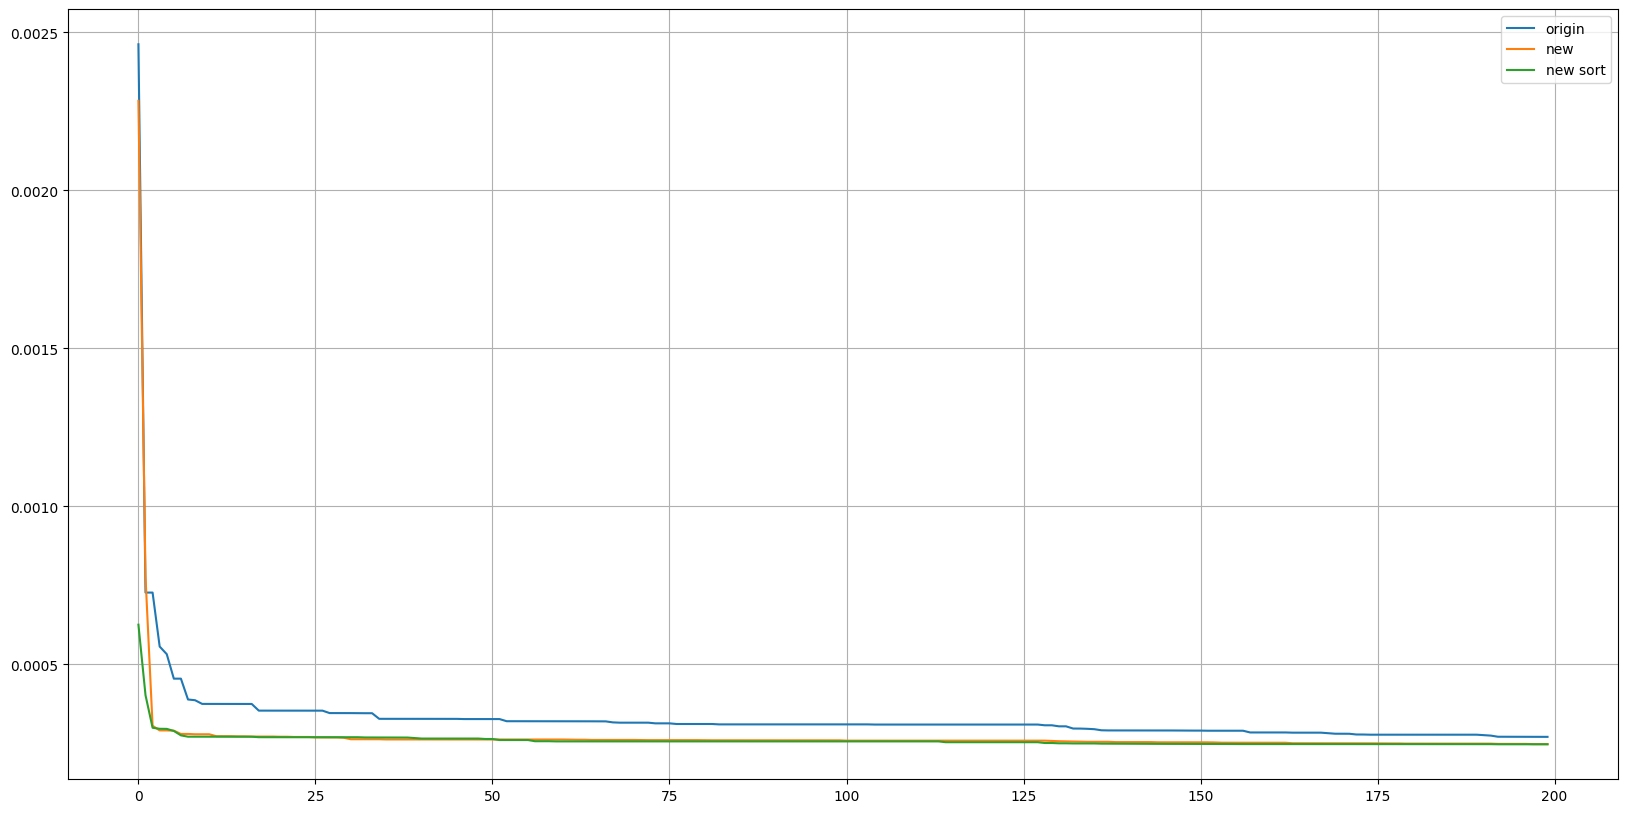

In [152]:
result_o = np.zeros(1000)
result_n = np.zeros(1000)
result_co = np.zeros(1000)
result_cn = np.zeros(1000)
result_vo = np.zeros(1000)
result_vn = np.zeros(1000)

for idx, task in enumerate(values_new):
    if(task[2:34] in hashs_cached):
        if(len(values_origin[task]) > 1000):
            for idx, value in enumerate(values_new_all[task][:1000]):
                result_n[idx] += value
                result_cn[idx] += 1
            for idx, value in enumerate(values_origin[task][:1000]):
                result_o[idx] += value
                result_co[idx] += 1
            for idx, value in enumerate(values_sort[task][:1000]):
                result_vo[idx] += value
                result_vn[idx] += 1

for idx, value in enumerate(result_n):
    result_n[idx] = result_n[idx] / result_cn[idx]
for idx, value in enumerate(result_o):
    result_o[idx] = result_o[idx] / result_co[idx]
for idx, value in enumerate(result_vo):
    result_vo[idx] = result_vo[idx] / result_vn[idx]
    
plt.figure(figsize=(20, 10))
plt.plot(result_o[:200], label="origin")
plt.plot(result_n[:200], label="new")
plt.plot(result_vo[:200], label="new sort")
plt.grid()
plt.legend()

["07f9fcad27bdd3233f86fe35a5185d33", [1, 224, 224, 3], [7, 7, 3, 64], [1, 1, 1, 64], [1, 112, 112, 64]]


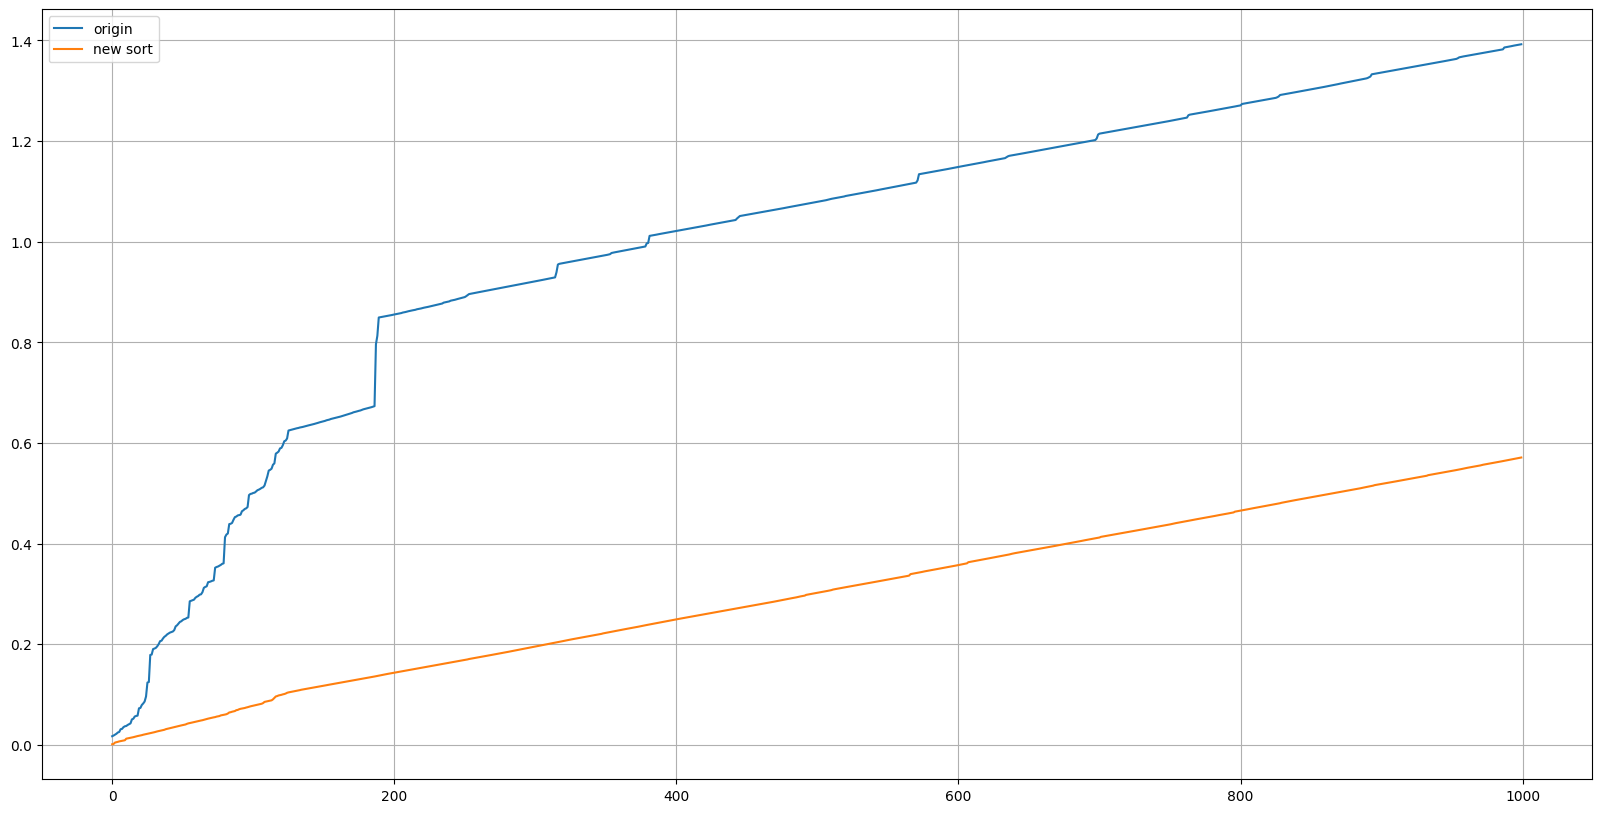

["cb5e1bf27549411a1320749a1d8e07ca", [1, 14, 14, 256], [1, 1, 256, 512], [1, 1, 1, 512], [1, 7, 7, 512]]


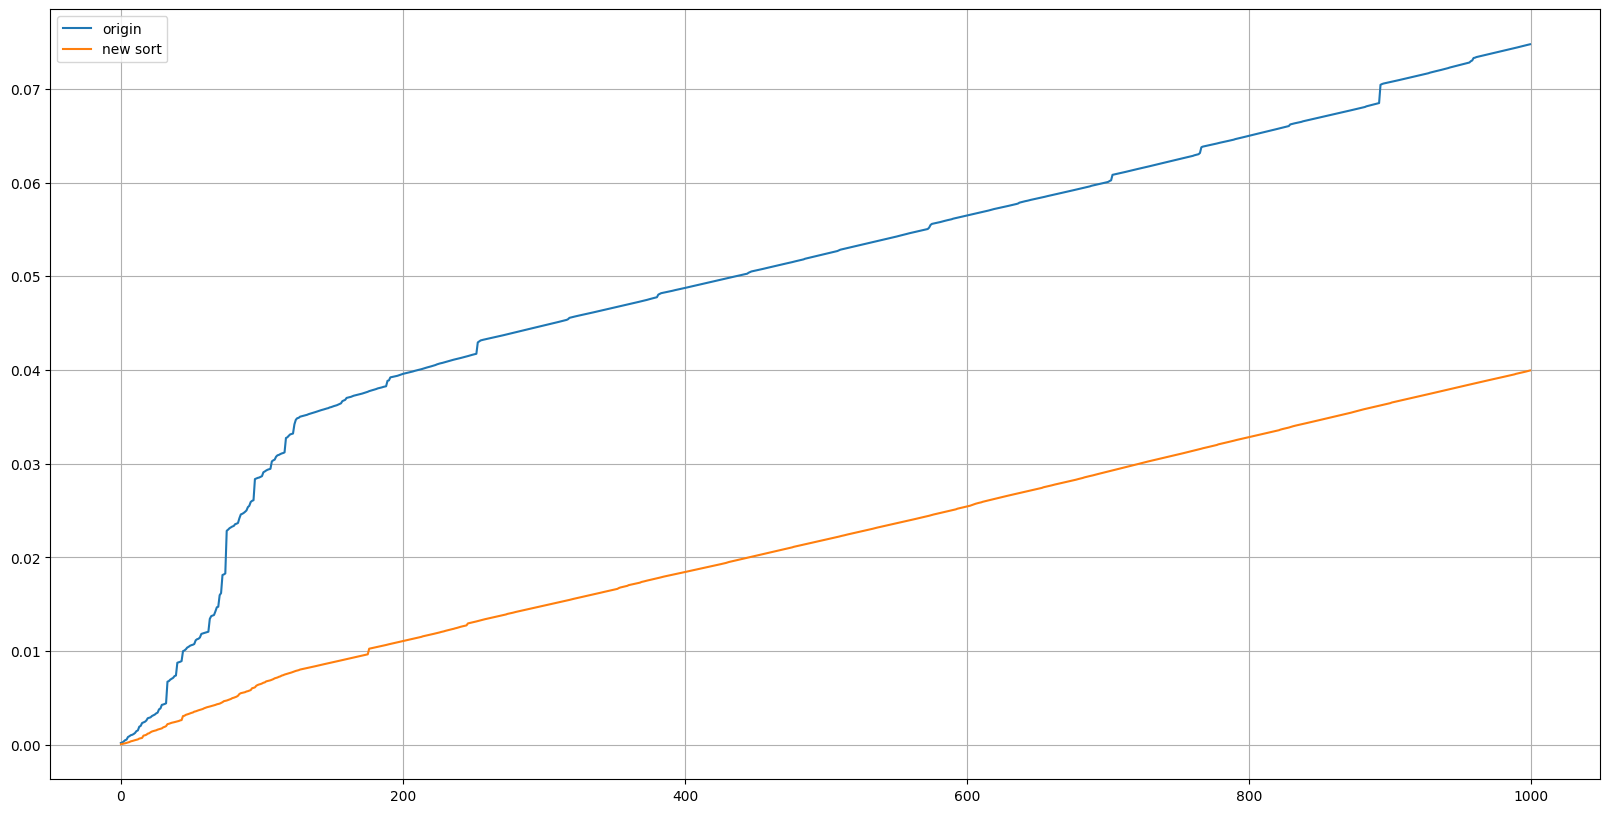

["d37380659057397544e056461ea3bad3", [1, 56, 56, 64], [3, 3, 64, 64], [1, 1, 1, 64], [1, 56, 56, 64]]


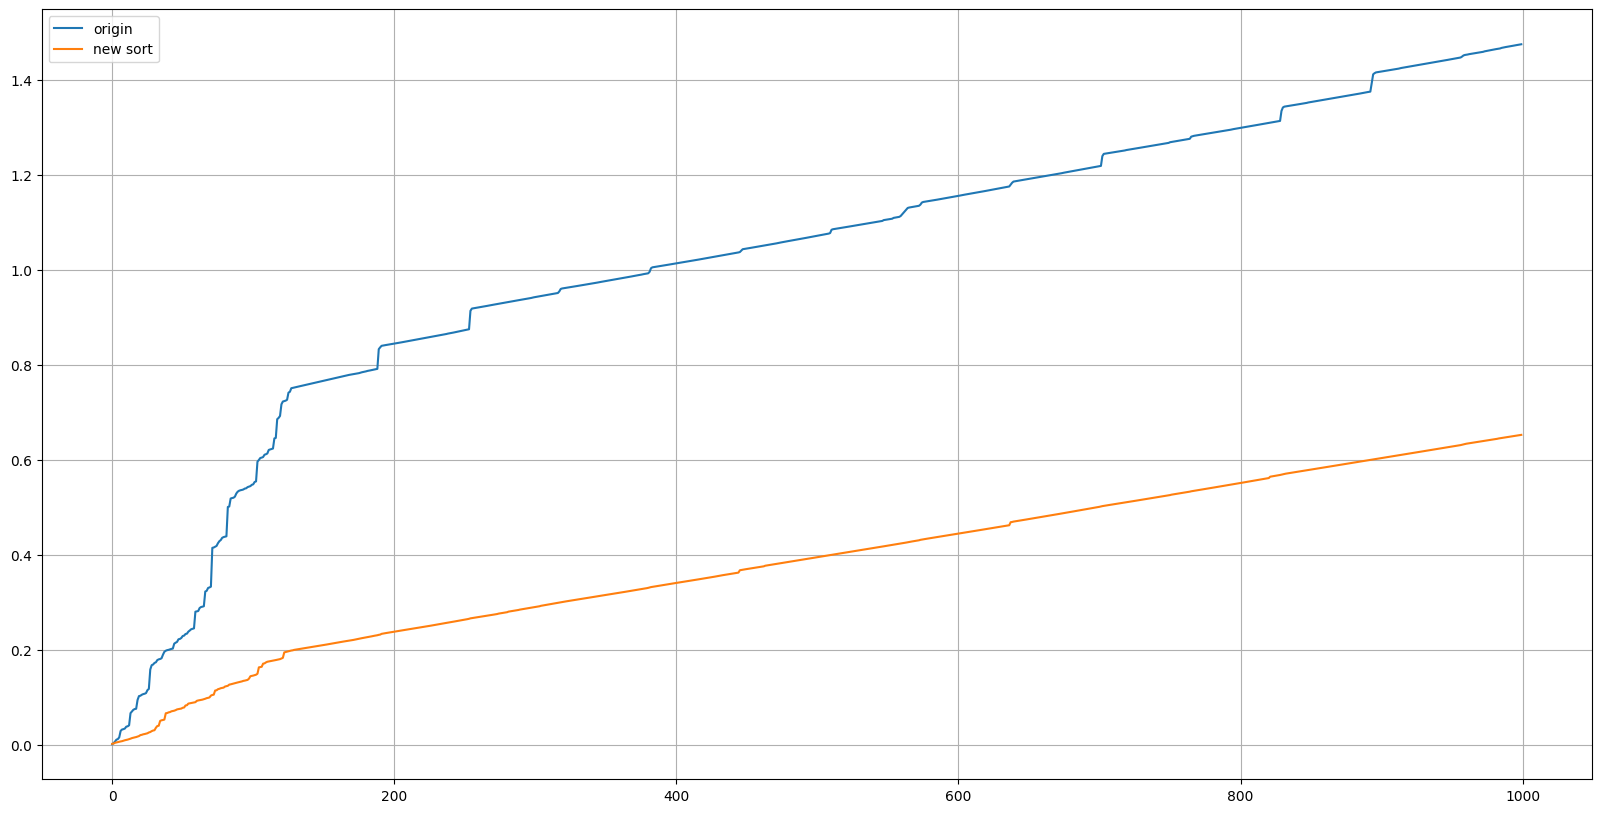

["cb5e1bf27549411a1320749a1d8e07ca", [1, 28, 28, 128], [1, 1, 128, 256], [1, 1, 1, 256], [1, 14, 14, 256]]


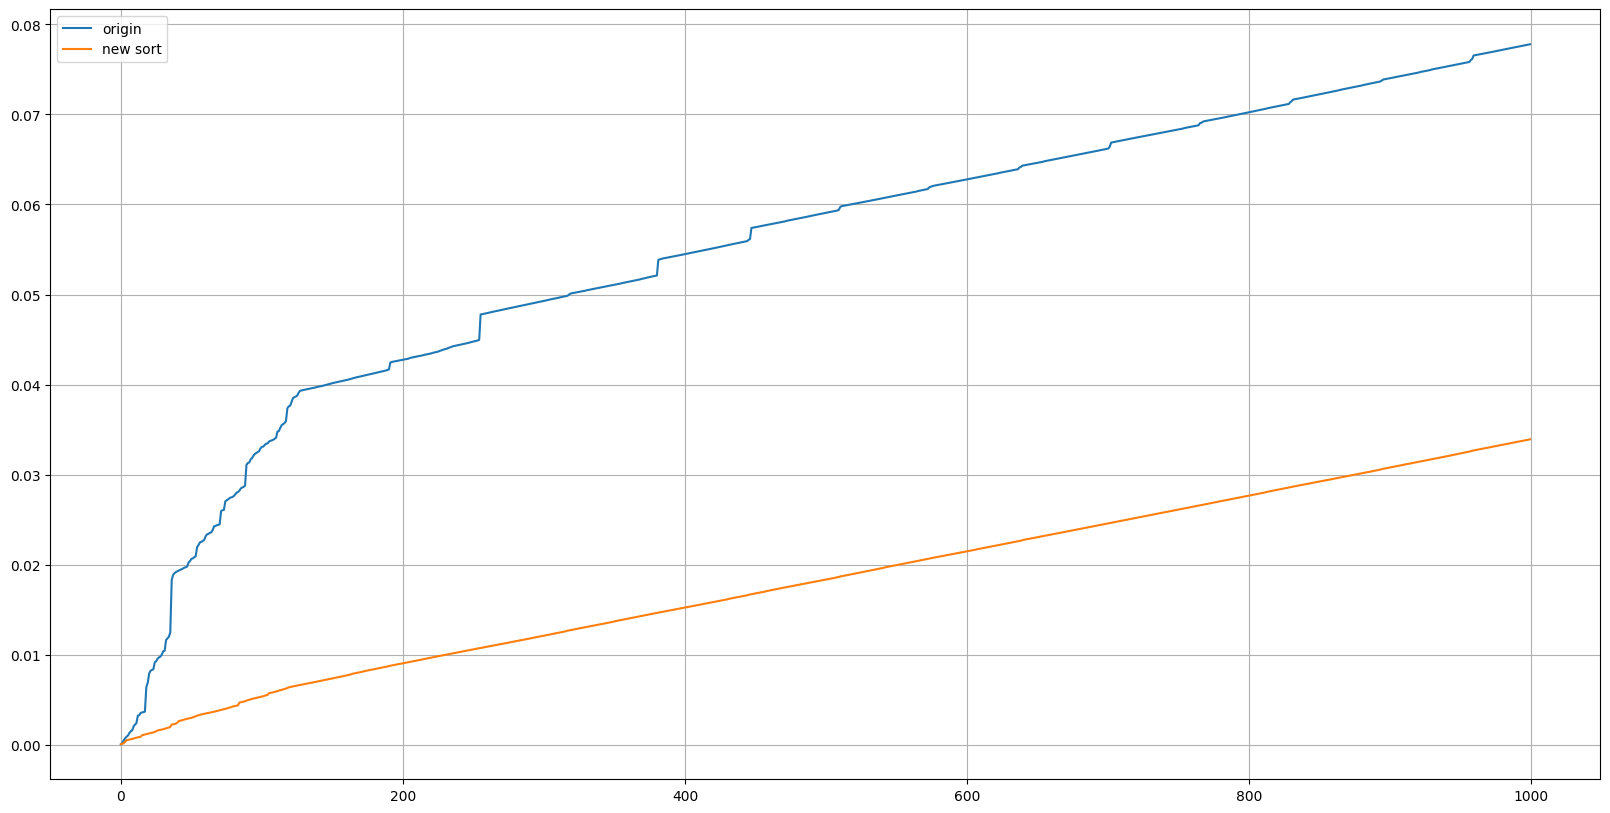

["07f9fcad27bdd3233f86fe35a5185d33", [1, 56, 56, 64], [3, 3, 64, 128], [1, 1, 1, 128], [1, 28, 28, 128]]


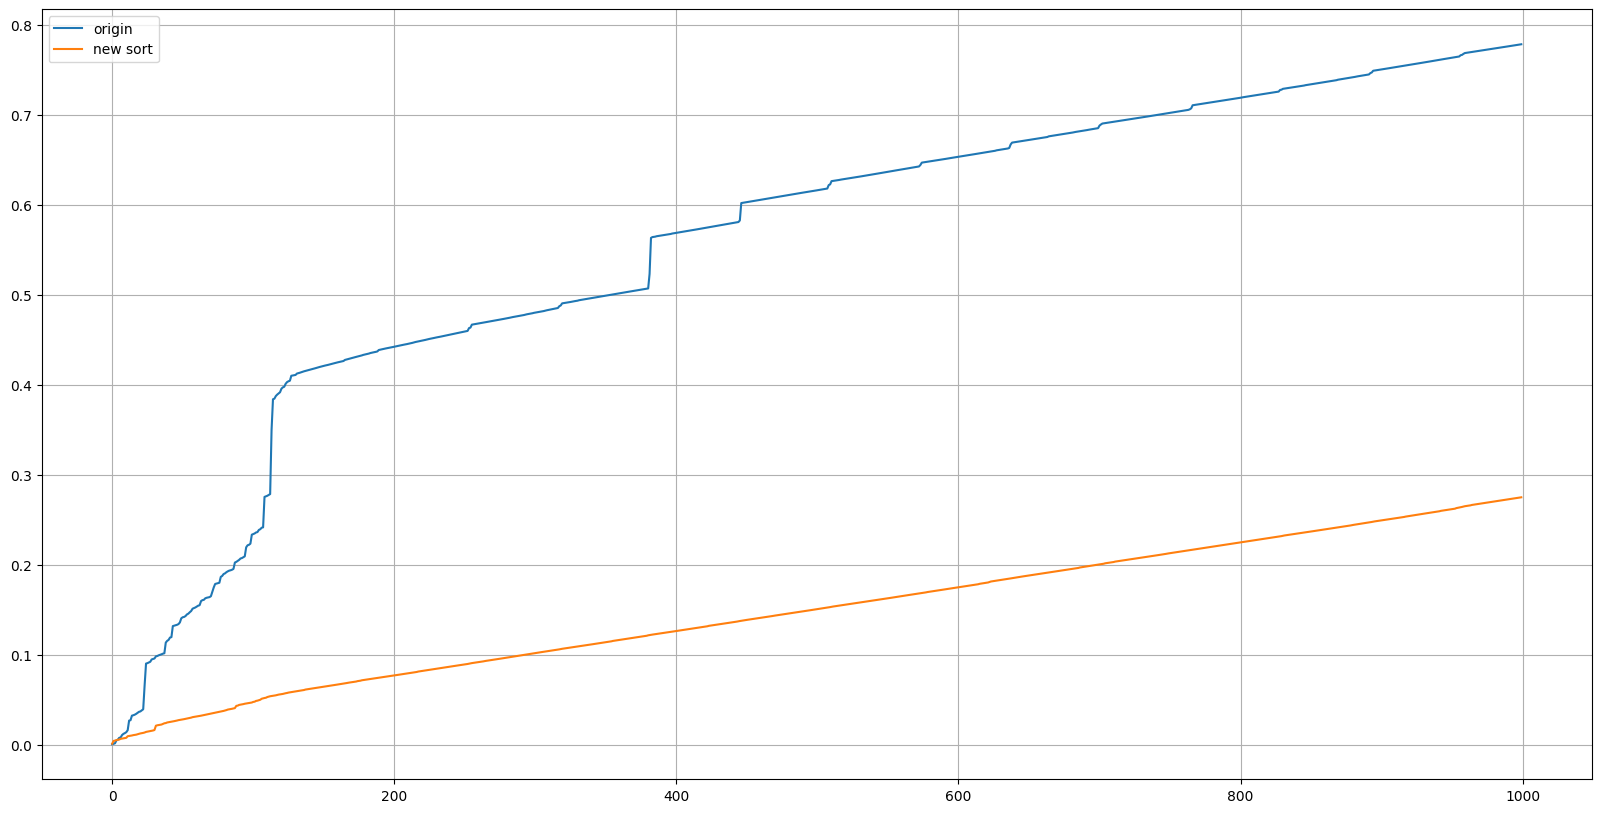

["cb5e1bf27549411a1320749a1d8e07ca", [1, 56, 56, 64], [1, 1, 64, 128], [1, 1, 1, 128], [1, 28, 28, 128]]


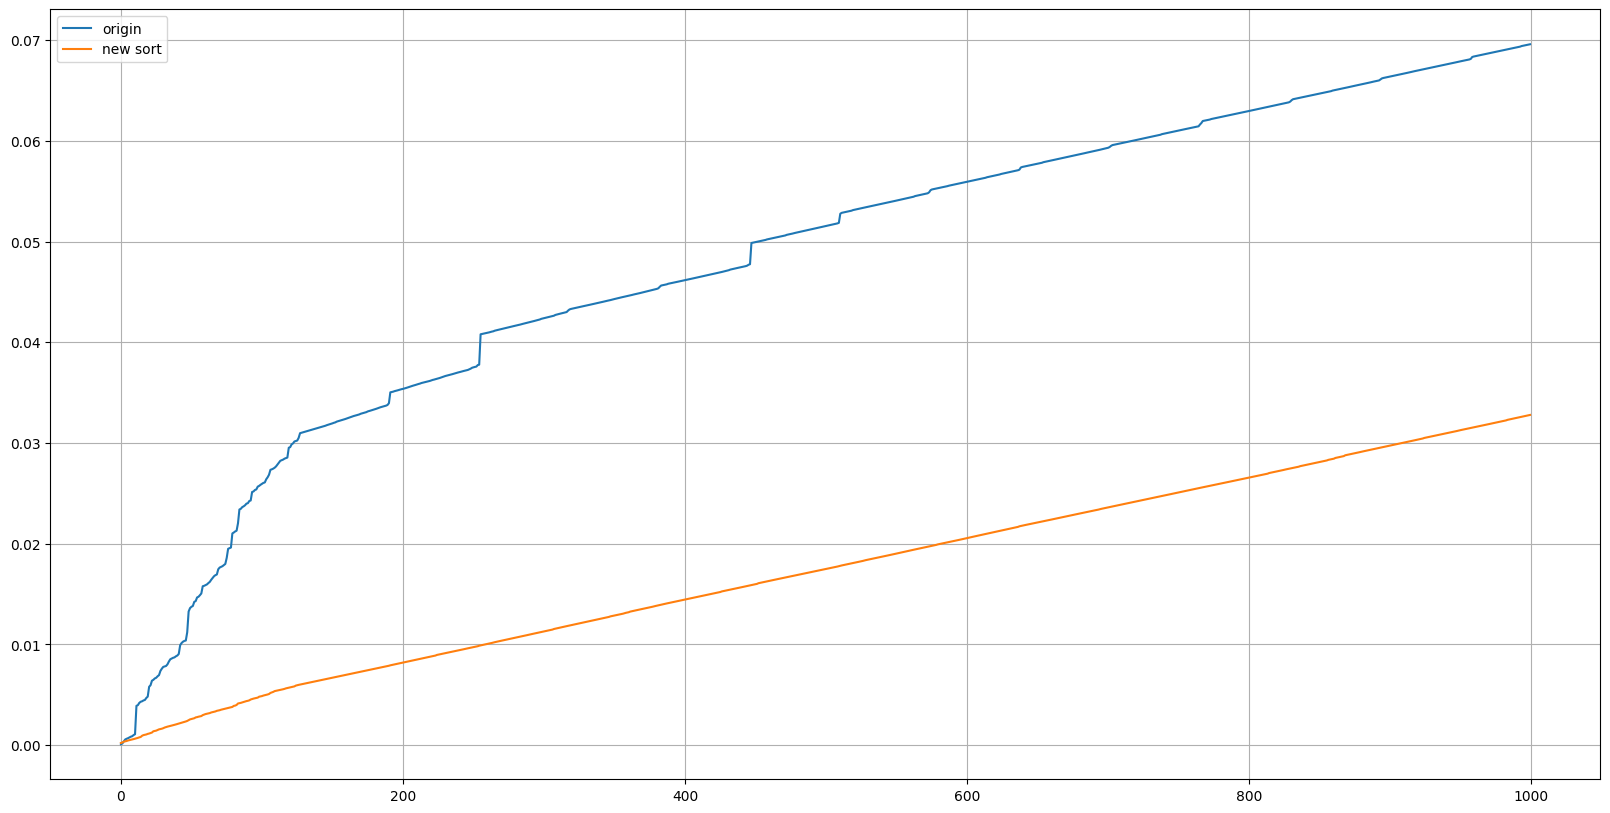

["07f9fcad27bdd3233f86fe35a5185d33", [1, 28, 28, 128], [3, 3, 128, 256], [1, 1, 1, 256], [1, 14, 14, 256]]


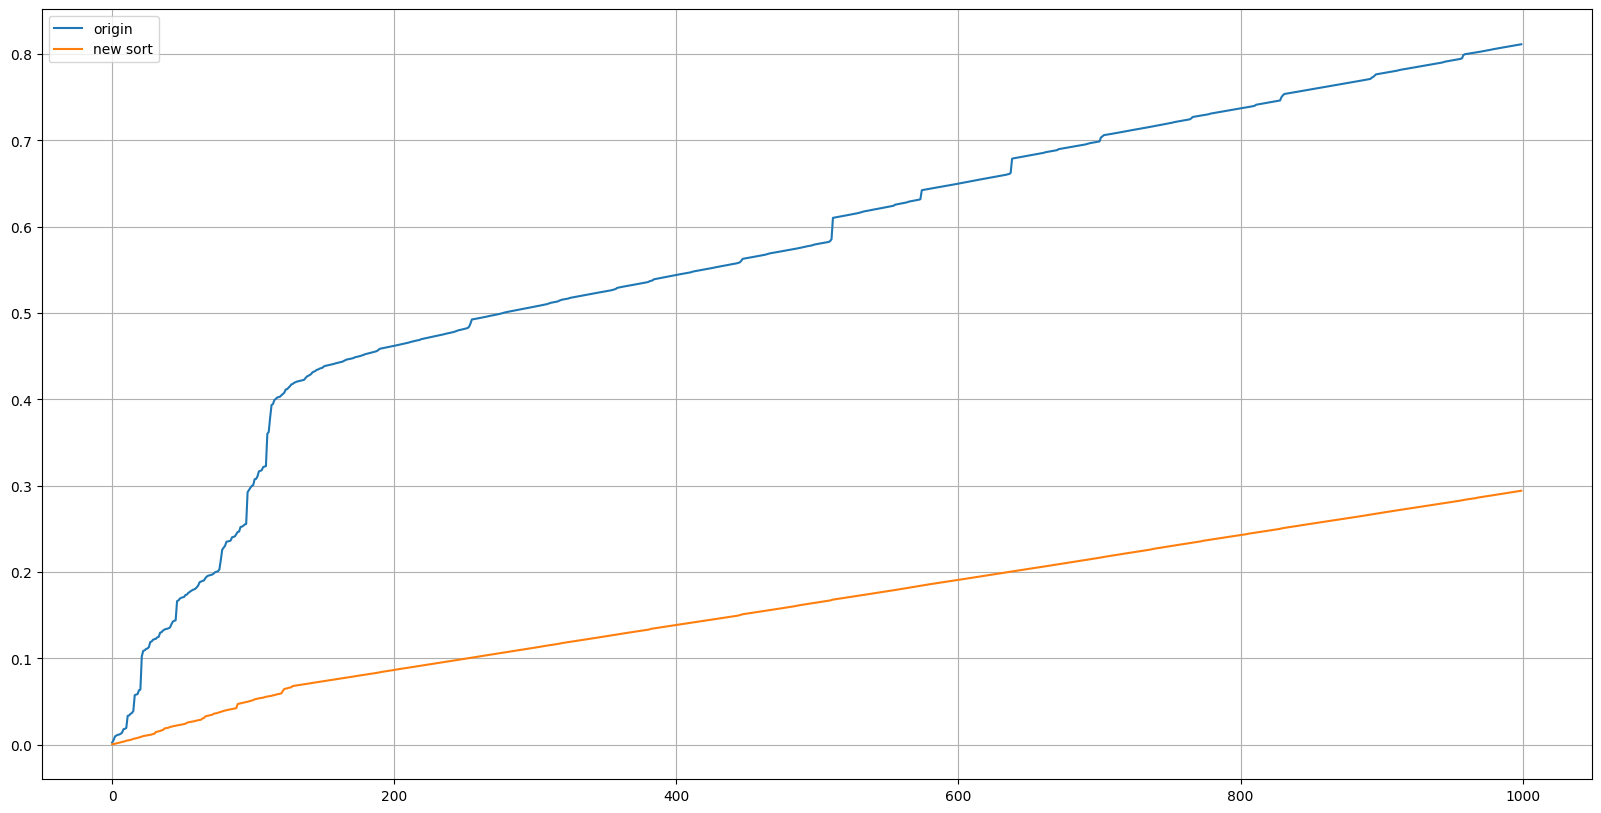

["cfd09cf1ca9e943f0ee12a18813a5c75", [1, 28, 28, 128], [6, 6, 128, 128], [1, 1, 1, 128], [1, 28, 28, 128]]


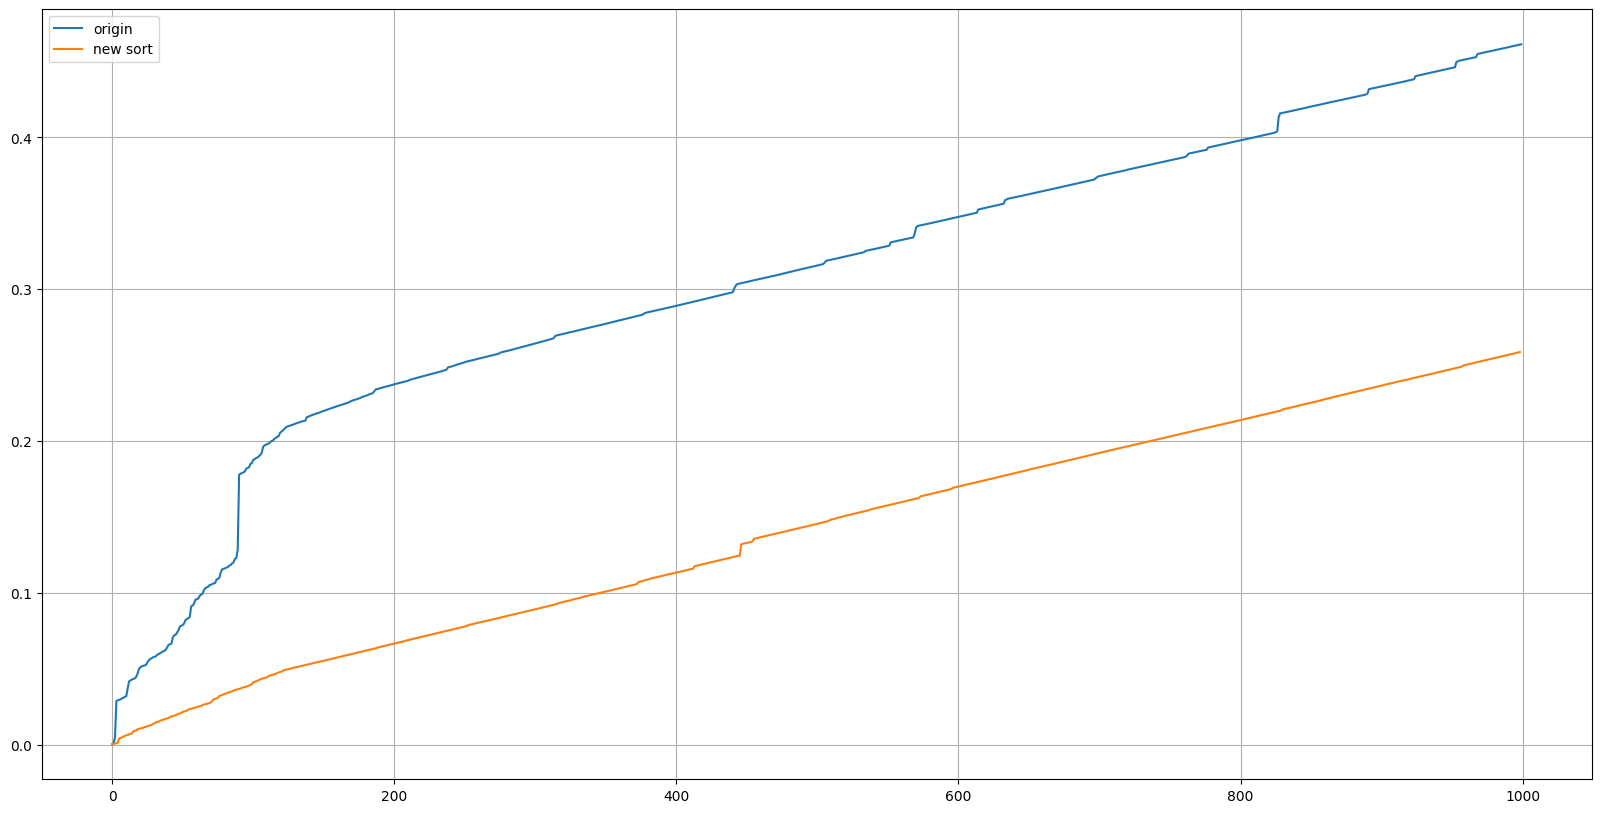

["d37380659057397544e056461ea3bad3", [1, 7, 7, 512], [3, 3, 512, 512], [1, 1, 1, 512], [1, 7, 7, 512]]


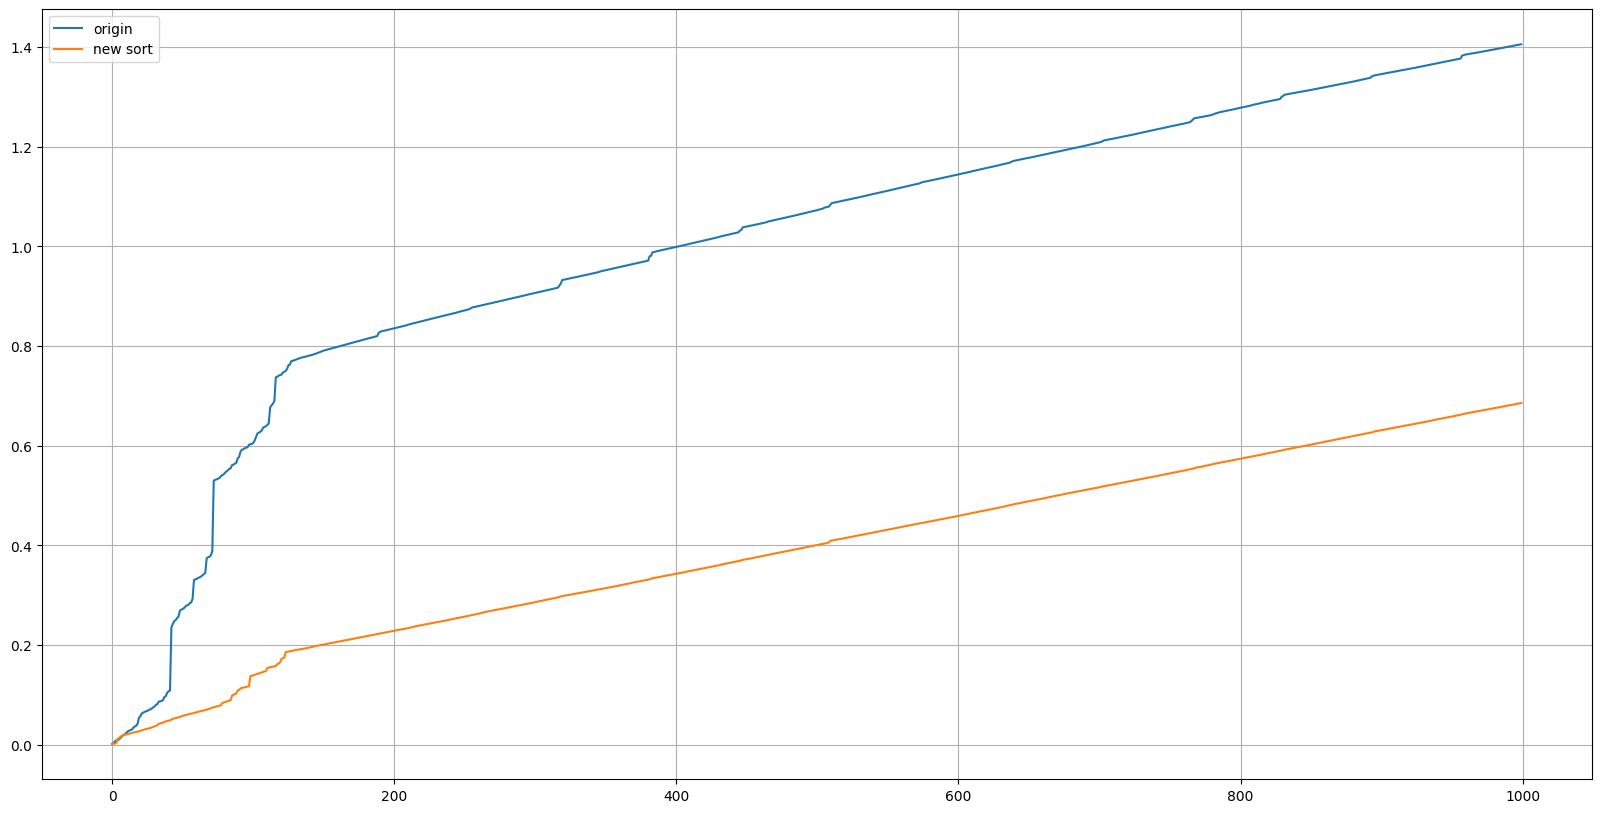

["07f9fcad27bdd3233f86fe35a5185d33", [1, 14, 14, 256], [3, 3, 256, 512], [1, 1, 1, 512], [1, 7, 7, 512]]


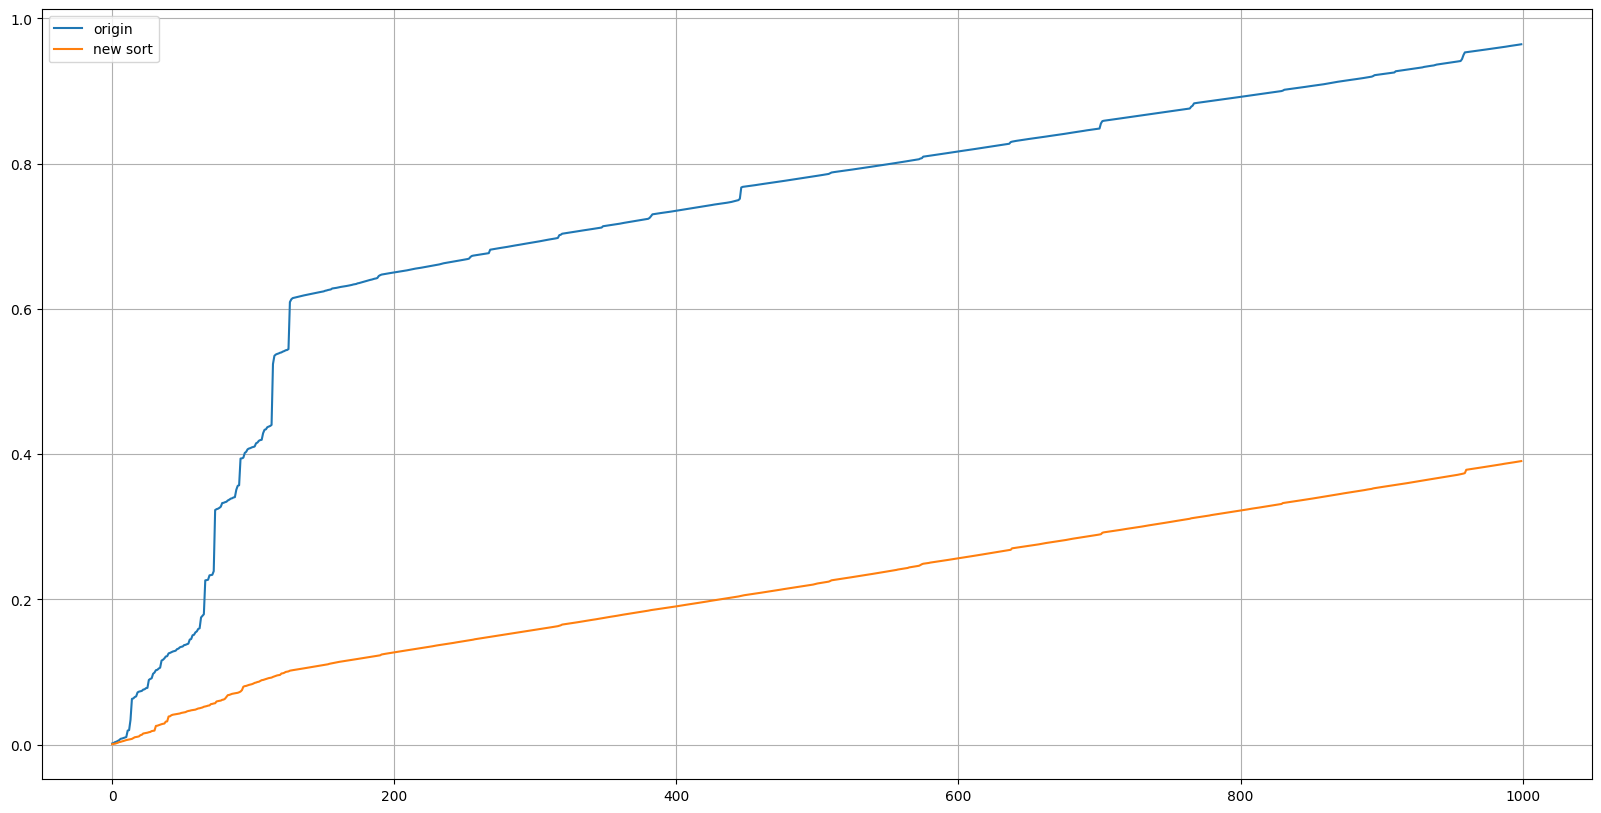

In [162]:
for idx, task in enumerate(values_new):
    if(task[2:34] in hashs_cached):
        if(len(values_origin[task])):
            if(len(values_origin[task]) > 1000):
                print(task)
                plt.figure(figsize=(20, 10))
                plt.plot(comp_origin[task][:1000], label="origin")
                #plt.plot(values_new_all[task], label="new")
                plt.plot(comp_sort[task], label="new sort")
                plt.legend()
                plt.grid()
                plt.show()